# Notebook 11 – Dimensionality Reduction

## 1. What is Dimensionality?

Dimensionality refers to the number of features or variables present in a dataset.

For example, if a dataset contains 10 input features, its dimensionality is 10.

When the number of features becomes very large, the dataset is called high-dimensional data.

In [1]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. High-Dimensional Data

High-dimensional data contains a large number of features.

Examples include:
- Text data with thousands of words.
- Images with thousands of pixels.
- Datasets containing many measurements.

High-dimensional data can increase computational cost and make it difficult to visualize and analyze the dataset.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 12


## 3. Curse of Dimensionality

The Curse of Dimensionality refers to the problems that can occur when the number of features becomes very large.

As dimensions increase:
- Data becomes more sparse.
- Computation becomes more expensive.
- Models may require more data.
- Overfitting can become more likely.

Dimensionality reduction can help reduce these problems.

In [3]:
print("Current dimensionality:", df.shape[1])

Current dimensionality: 12


## 4. Why Reduce Dimensions?

Dimensionality reduction is used to reduce the number of features while trying to preserve the most useful information.

Main reasons include:
- Reduce computational complexity.
- Remove redundant information.
- Reduce noise.
- Improve visualization.
- Reduce the risk of overfitting.
- Make high-dimensional data easier to understand.

In [4]:
print("Dimensionality reduction can simplify high-dimensional data.")

Dimensionality reduction can simplify high-dimensional data.


## 5. Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique that transforms the original features into a smaller number of new features called Principal Components.

PCA tries to preserve as much variation or information in the data as possible.

The new components are combinations of the original features and are ordered according to the amount of variance they explain.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

X = df[features].fillna(df[features].median())

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_pca[:5]

array([[ 1.14066038, -0.07651959],
       [-1.76844507,  0.13347858],
       [ 0.87919636, -0.72660565],
       [-1.45810298,  0.07155456],
       [ 0.56125154, -0.94371301]])

## 6. Principal Components

Principal Components are the new features created by PCA.

The first principal component captures the maximum possible variance.

The second principal component captures the maximum remaining variance while being independent of the first component.

More components can be created, but we usually keep only the components needed to preserve enough information.

In [6]:
print("PCA components:")
print(pca.components_)

PCA components:
[[ 0.67894999 -0.45765542  0.12473552  0.03185044 -0.55946851]
 [-0.05164286 -0.31523619  0.61518308  0.61995457  0.36764828]]


## 7. Explained Variance

Explained Variance tells us how much information or variation from the original dataset is captured by each Principal Component.

A higher explained variance means that the component preserves more information.

The cumulative explained variance can help us decide how many components to keep.

In [7]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance: [0.33960812 0.32520788]
Total explained variance: 0.664815996955328


## 8. Eigenvectors and Eigenvalues

PCA uses eigenvectors and eigenvalues mathematically.

- Eigenvectors represent the directions of the new Principal Components.
- Eigenvalues represent the amount of variance captured in those directions.

In PCA, components with larger eigenvalues explain more variation in the data.

In [8]:
print("Eigenvalues:")
print(pca.explained_variance_)

Eigenvalues:
[1.6999485  1.62786641]


## 9. PCA Transformation

PCA transforms the original features into a new lower-dimensional feature space.

Here, five original numerical features are transformed into two Principal Components.

The resulting features are called PC1 and PC2.

In [9]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,1.140660,-0.076520
1,-1.768445,0.133479
2,0.879196,-0.726606
3,-1.458103,0.071555
4,0.561252,-0.943713


## 10. PCA Visualization

PCA can be used to visualize high-dimensional data in two or three dimensions.

By plotting PC1 against PC2, we can observe patterns, groups, or separation in the transformed data.

This is especially useful when the original dataset contains many features.

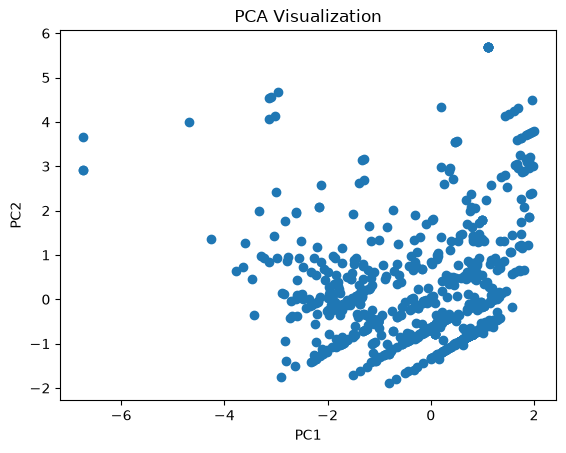

In [10]:
import matplotlib.pyplot as plt

plt.scatter(pca_df["PC1"], pca_df["PC2"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

## 11. Advantages of PCA

PCA provides several benefits:

- Reduces the number of features.
- Helps visualize high-dimensional data.
- Can reduce redundant information.
- Can reduce computational complexity.
- Can help reduce noise in some datasets.

PCA is especially useful when many numerical features contain overlapping information.

In [11]:
print("Original features:", len(features))
print("Reduced features:", X_pca.shape[1])

Original features: 5
Reduced features: 2


## 12. Limitations of PCA

PCA also has some limitations:

- Principal Components can be difficult to interpret.
- PCA may lose some information.
- It works mainly with numerical data.
- Features should generally be scaled before PCA.
- PCA is sensitive to feature scaling and outliers.
- The new components may not have clear business meaning.

In [12]:
print("PCA may reduce interpretability because components combine multiple features.")

PCA may reduce interpretability because components combine multiple features.


## 13. When to Use PCA

PCA can be useful when:

- The dataset has many numerical features.
- Features are highly correlated.
- Visualization of high-dimensional data is required.
- Computational complexity needs to be reduced.
- Reducing feature dimensions is more important than maintaining direct feature interpretability.

In [13]:
print("PCA is suitable for reducing many correlated numerical features.")

PCA is suitable for reducing many correlated numerical features.


## 14. When Not to Use PCA

PCA may not be suitable when:

- The original features need to remain interpretable.
- The dataset has only a small number of features.
- Features contain important categorical information.
- The transformed components are difficult to explain to business users.

In such cases, selecting the original important features may be better than creating new components.

In [14]:
print("Use feature selection instead when original feature interpretability is important.")

Use feature selection instead when original feature interpretability is important.


## 15. Required Documentation for PCA Features

PCA creates new features called Principal Components.

For every important engineered feature, document:

### Feature Name
Name of the newly created feature.

### Source Columns
Original columns used by PCA.

### Logic
PCA creates a weighted combination of the original numerical features.

### Reason
Reduce the number of dimensions while preserving important information.

### Business Meaning
The component represents a combination of information from multiple original features. It may not have one direct business meaning.

### ML Relevance
Principal Components can reduce feature dimensions, redundancy, and computational complexity.

### Leakage Check
PCA must be fitted only on the training data in a real Machine Learning workflow. Test data should only be transformed using the fitted PCA.

### Final Decision
Retain if dimensionality reduction improves the ML workflow; otherwise, use the original features.

For this demonstration:
- PC1 → Retain
- PC2 → Retain

In [15]:
documentation = pd.DataFrame([
    ["PC1", "Pclass, Age, SibSp, Parch, Fare",
     "First principal component", "Reduce dimensions",
     "Combination of original features",
     "Preserves important variation", "Fit PCA on train only", "Retain"],

    ["PC2", "Pclass, Age, SibSp, Parch, Fare",
     "Second principal component", "Capture additional variation",
     "Combination of original features",
     "Provides additional information", "Fit PCA on train only", "Retain"]
], columns=[
    "Feature Name", "Source Columns", "Logic", "Reason",
    "Business Meaning", "ML Relevance", "Leakage Check",
    "Final Decision"
])

documentation

,Feature Name,Source Columns,Logic,Reason,Business Meaning,ML Relevance,Leakage Check,Final Decision
0,PC1,"Pclass, Age, SibSp, Parch, Fare",First principal component,Reduce dimensions,Combination of original features,Preserves important variation,Fit PCA on train only,Retain
1,PC2,"Pclass, Age, SibSp, Parch, Fare",Second principal component,Capture additional variation,Combination of original features,Provides additional information,Fit PCA on train only,Retain


## 16. Conclusion

Dimensionality Reduction reduces the number of features while trying to preserve important information.

In this notebook, we used PCA to transform five numerical Titanic features into two Principal Components.

PCA is useful for reducing dimensionality and visualization, but the resulting components can be harder to interpret.

The main takeaway is:

**PCA reduces dimensions by creating new features that preserve as much important variation as possible.**

In [16]:
print("PCA dimensionality reduction completed successfully.")
print("Original features:", len(features))
print("PCA features:", X_pca.shape[1])


PCA dimensionality reduction completed successfully.
Original features: 5
PCA features: 2
